# Market Making with Alpha - Order Book Imbalance
# 基于阿尔法的做市策略 - 订单簿失衡

## Overview
## 概述

Order Book Imbalance, also known as Order Flow Imbalance, is a widely recognized microstructure indicator often analyzed alongside trade flow. This concept has several derivatives, including the Micro-Price, VAMP (Volume Adjusted Mid Price), Weighted-Depth Order Book Price, and Static Order Book Imbalance, among others.

订单簿失衡，又称订单流失衡，是一种广为人知的微观结构指标，通常会与交易流一同进行分析。这一概念有多种衍生形式，包括微价格、VAMP（成交量调整中间价）、加权深度订单簿价格以及静态订单簿失衡等。

* Static Order Book Imbalance
  
* 静态订单簿失衡
$$
Static\ Order\ Book\ Imbalance = {{\sum_{i}^NQ_{bid}^i - \sum_{i}^NQ_{ask}^i} \over {\sum_{i}^NQ_{bid}^i + \sum_{i}^NQ_{ask}^i}}
$$

Through standardization, an alternative expression for order imbalance can be obtained, one that does not include the normalization numerator.

通过标准化，可以得出一种不同于“订单失衡”的表达方式，这种方式不包含“标准化分子”。

$$
Standardized\ Order\ Book\ Imbalance = standardize({\sum_{i}^NQ_{bid}^i - \sum_{i}^NQ_{ask}^i})
$$

* Volume Adjusted Mid Price  
Be aware that price and quantity are cross-multiplied between bid and ask sides.

* 成交量调整后的中间价格
请注意，价格和数量在买价和卖价两侧是相互乘积计算的。

$$
VAMP_{bbo} = {P_{best\ bid} \times Q_{best\ ask} + P_{best\ ask} \times Q_{best\ bid} \over {Q_{best\ bid} + Q_{best\ ask}}}
$$
$$
VAMP_N = {\sum_{i}^N{P_{bid}^i \times Q_{ask}^i} + \sum_{i}^N{P_{ask}^i \times Q_{bid}^i} \over {\sum_{i}^NQ_{bid}^i + \sum_{i}^NQ_{ask}^i}}
$$
where N is usually defined as a percentage of the mid price. For 1% market depth, compute bid side down to mid × 0.99 and ask side up to mid × 1.01.

其中 N 通常被定义为中间价的百分比。对于 1%的市场深度，计算买方一侧应向下调整至中间价的 0.99 倍，卖方一侧则应向上调整至中间价的 1.01 倍。

* Weighted-Depth Order Book Price  
Be aware that price and quantity are multiplied within the same side

* 加权深度订单簿价格
请注意，价格和数量在相同的一侧是相乘计算的。

$$
Weighted-Depth\ Order\ Book\ Price = {\sum_{i}^N{P_{bid}^i \times Q_{bid}^i} + \sum_{i}^N{P_{ask}^i \times Q_{ask}^i} \over {\sum_{i}^NQ_{bid}^i + \sum_{i}^NQ_{ask}^i}}
$$
In this case, N—unlike in VAMP—is defined by a fixed total quantity. For 500 qty of market depth, compute bid side down to its total quantity reachs 500 and ask side up to its total quantity reachs 500. Alternatively, you can use notional value instead of quantity.

在这种情况下，N（与 VAMP 不同）是由一个固定的总量来定义的。对于 500 个单位的市场深度，计算买方一侧要一直向下调整，直到其总量达到 500，同时卖方一侧要一直向上调整，直到其总量达到 500。或者，您也可以使用名义价值而非数量。

* Another variation is to combine VAMP with Weighted-Depth Order Book Price.
  
* 另一种变体是将 VAMP 与加权深度订单簿价格相结合。
$$
P_{effective\ bid}^N = {\sum_{i}^N{P_{bid}^i \times Q_{bid}^i} \over {\sum_{i}^NQ_{bid}^i}}
$$
$$
P_{effective\ ask}^N = {\sum_{i}^N{P_{ask}^i \times Q_{ask}^i} \over {\sum_{i}^NQ_{ask}^i}}
$$
$$
Q_{effective\ bid}^N = \sum_{i}^NQ_{bid}^i
$$
$$
Q_{effective\ ask}^N = \sum_{i}^NQ_{ask}^i
$$
$$
VAMP_{effective}^N = {{P_{effective\ bid}^N \times Q_{effective\ ask}^N + P_{effective\ ask}^N \times Q_{effective\ bid}^N} \over {Q_{effective\ bid}^N + Q_{effective\ ask}^N}}
$$
where N is defined just like VAMP.

其中 N 的定义方式与 VAMP 完全相同。

You can also apply other time-series techniques or statistical adjustments to these derived order book indicators, such as standardization.

您还可以对这些衍生的订单簿指标应用其他时间序列技术或统计调整方法，例如标准化处理。

Extensive information on these indicators is available online. In the following examples, we begin by testing the standardized order book imbalance and then evaluate the other indicators in subsequent examples.

关于这些指标的大量信息可在网上获取。在接下来的示例中，我们首先测试标准化的订单簿失衡情况，然后在后续示例中评估其他指标。

### Reference
### 参考文献
* [The Micro-Price: A High Frequency Estimator of Future Prices](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2970694)
[《微价格：未来价格的高频估算方法》](https://papers.ssrn.com/sol3/papers.cfm？abstract_id=2970694)
  
* [Mind the Gaps: Short-Term Crypto Price Prediction](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4351947)
[留意差距：短期加密货币价格预测](https://papers.ssrn.com/sol3/papers.cfm？abstract_id=4351947)
  
* [Market microstructure signals](https://blog.headlandstech.com/2017/08/)
[市场微观结构信号](https://blog.headlandstech.com/2017/08/)
<div class="alert alert-info">
    
**Note:** This example is for educational purposes only and demonstrates effective strategies for high-frequency market-making schemes. All backtests are based on a 0.005% rebate, the highest market maker rebate available on Binance Futures. See <a href="https://www.binance.com/en/support/announcement/binance-updates-usd%E2%93%A2-margined-futures-liquidity-provider-program-2024-06-03-fefc6aa25e0947e2bf745c1c56bea13e">Binance Upgrades USDⓢ-Margined Futures Liquidity Provider Program</a> for more details.

**注意：** 本示例仅用于教育目的，旨在展示高频市场撮合方案的有效策略。所有回测均基于 0.005% 的返点费率，这是在币安期货上可获得的最高市场撮合返点费率。详情请参阅 <a href="https://www.binance.com/en/support/announcement/binance-upgrades-usd%E2%93%A2-margined-futures-liquidity-provider-program-2024-06-03-fefc6aa25e0947e2bf745c1c56bea13e">币安升级 USDⓢ-保证金期货流动性提供者计划</a> 以获取更多信息。
    
</div>

In [1]:
import numpy as np

from numba import njit, uint64
from numba.typed import Dict

from hftbacktest import (
    BacktestAsset,
    ROIVectorMarketDepthBacktest,
    GTX,
    LIMIT,
    BUY,
    SELL,
    BUY_EVENT,
    SELL_EVENT,
    Recorder
)
from hftbacktest.stats import LinearAssetRecord

@njit
def obi_mm(
    hbt,
    stat,
    half_spread,
    skew,
    c1,
    looking_depth,
    interval,
    window,
    order_qty_dollar,
    max_position_dollar,
    grid_num,
    grid_interval,
    roi_lb,
    roi_ub
):
    asset_no = 0
    imbalance_timeseries = np.full(30_000_000, np.nan, np.float64)

    tick_size = hbt.depth(0).tick_size
    lot_size = hbt.depth(0).lot_size
    
    t = 0
    roi_lb_tick = int(round(roi_lb / tick_size))
    roi_ub_tick = int(round(roi_ub / tick_size))
    
    while hbt.elapse(interval) == 0:
        hbt.clear_inactive_orders(asset_no)
        
        depth = hbt.depth(asset_no)
        position = hbt.position(asset_no)
        orders = hbt.orders(asset_no)

        best_bid = depth.best_bid
        best_ask = depth.best_ask
        
        mid_price = (best_bid + best_ask) / 2.0
        
        sum_ask_qty = 0.0
        from_tick = max(depth.best_ask_tick, roi_lb_tick)
        upto_tick = min(int(np.floor(mid_price * (1 + looking_depth) / tick_size)), roi_ub_tick)
        for price_tick in range(from_tick, upto_tick):
            sum_ask_qty += depth.ask_depth[price_tick - roi_lb_tick]
                
        sum_bid_qty = 0.0
        from_tick = min(depth.best_bid_tick, roi_ub_tick)
        upto_tick = max(int(np.ceil(mid_price * (1 - looking_depth) / tick_size)), roi_lb_tick)
        for price_tick in range(from_tick, upto_tick, -1):
            sum_bid_qty += depth.bid_depth[price_tick - roi_lb_tick]

        imbalance_timeseries[t] = sum_bid_qty - sum_ask_qty
        
        # Standardizes the order book imbalance timeseries for a given window
        m = np.nanmean(imbalance_timeseries[max(0, t + 1 - window):t + 1])
        s = np.nanstd(imbalance_timeseries[max(0, t + 1 - window):t + 1]) 
        alpha = np.divide(imbalance_timeseries[t] - m, s)
    
        #--------------------------------------------------------
        # Computes bid price and ask price.
        
        order_qty = max(round((order_qty_dollar / mid_price) / lot_size) * lot_size, lot_size)
        fair_price = mid_price + c1 * alpha
        
        normalized_position = position / order_qty
        
        reservation_price = fair_price - skew * normalized_position

        bid_price = min(np.round(reservation_price - half_spread), best_bid)
        ask_price = max(np.round(reservation_price + half_spread), best_ask)
        
        bid_price = np.floor(bid_price / tick_size) * tick_size
        ask_price = np.ceil(ask_price / tick_size) * tick_size
        
        #--------------------------------------------------------
        # Updates quotes.
        
        # Creates a new grid for buy orders.
        new_bid_orders = Dict.empty(np.uint64, np.float64)
        if position * mid_price < max_position_dollar and np.isfinite(bid_price):
            for i in range(grid_num):
                bid_price_tick = round(bid_price / tick_size)
                
                # order price in tick is used as order id.
                new_bid_orders[uint64(bid_price_tick)] = bid_price
                
                bid_price -= grid_interval

        # Creates a new grid for sell orders.
        new_ask_orders = Dict.empty(np.uint64, np.float64)
        if position * mid_price > -max_position_dollar and np.isfinite(ask_price):
            for i in range(grid_num):
                ask_price_tick = round(ask_price / tick_size)
                
                # order price in tick is used as order id.
                new_ask_orders[uint64(ask_price_tick)] = ask_price

                ask_price += grid_interval
                
        order_values = orders.values();
        while order_values.has_next():
            order = order_values.get()
            # Cancels if a working order is not in the new grid.
            if order.cancellable:
                if (
                    (order.side == BUY and order.order_id not in new_bid_orders)
                    or (order.side == SELL and order.order_id not in new_ask_orders)
                ):
                    hbt.cancel(asset_no, order.order_id, False)
                    
        for order_id, order_price in new_bid_orders.items():
            # Posts a new buy order if there is no working order at the price on the new grid.
            if order_id not in orders:
                hbt.submit_buy_order(asset_no, order_id, order_price, order_qty, GTX, LIMIT, False)
                
        for order_id, order_price in new_ask_orders.items():
            # Posts a new sell order if there is no working order at the price on the new grid.
            if order_id not in orders:
                hbt.submit_sell_order(asset_no, order_id, order_price, order_qty, GTX, LIMIT, False)
        
        t += 1
        
        if t >= len(imbalance_timeseries):
            raise Exception
        
        # Records the current state for stat calculation.
        stat.record(hbt)

In [2]:
%%time

roi_lb = 0
roi_ub = 3000

latency_data = np.concatenate(
# [np.load('latency/live_order_latency_{}.npz'.format(date))['data'] for date in range(20230501, 20230532)]
[np.load('usdm/feed_latency_ethusdc_{}.npz'.format(date))['data'] for date in range(20260302, 20260303)]
)

asset = (
    BacktestAsset()
        .data(['usdm/ethusdc_{}.npz'.format(date) for date in range(20260302, 20260303)])
        .initial_snapshot('usdm/ethusdc_20260301_eod.npz')
        .linear_asset(1.0) 
        .intp_order_latency(latency_data)
        .power_prob_queue_model(3)
        .no_partial_fill_exchange()
        .trading_value_fee_model(-0.00005, 0.0007)
        .tick_size(0.1)
        .lot_size(0.001)
        .roi_lb(roi_lb)    
        .roi_ub(roi_ub)
)

hbt = ROIVectorMarketDepthBacktest([asset])

recorder = Recorder(1, 30_000_000)

half_spread = 80
skew = 3.5
c1 = 160
depth = 0.025 # 2.5% from the mid price
interval = 1_000_000_000 # 1s
window = 3_600_000_000_000 / interval # 1hour
order_qty_dollar = 50_000
max_position_dollar = order_qty_dollar * 50
grid_num = 1
grid_interval = hbt.depth(0).tick_size

obi_mm(
    hbt,
    recorder.recorder,
    half_spread,
    skew,
    c1,
    depth,
    interval,
    window,
    order_qty_dollar,
    max_position_dollar,
    grid_num,
    grid_interval,
    roi_lb,
    roi_ub
)

hbt.close()

recorder.to_npz('usdm/obi_ethusdc.npz')

CPU times: user 10.6 s, sys: 1.53 s, total: 12.1 s
Wall time: 13.3 s


In [3]:
data = np.load('usdm/obi_ethusdc.npz')['0']
stats = (
    LinearAssetRecord(data)
        .resample('5m')
        .stats(book_size=2_500_000)
)
stats.summary()

start,end,SR,Sortino,Return,MaxDrawdown,DailyNumberOfTrades,DailyTurnover,ReturnOverMDD,ReturnOverTrade,MaxPositionValue
datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-03-02 00:00:00,2026-03-02 23:55:00,-15.820541,-18.561559,-0.025362,0.041559,21421.379791,428.427258,-0.61026,-0.000059,2.5417e6


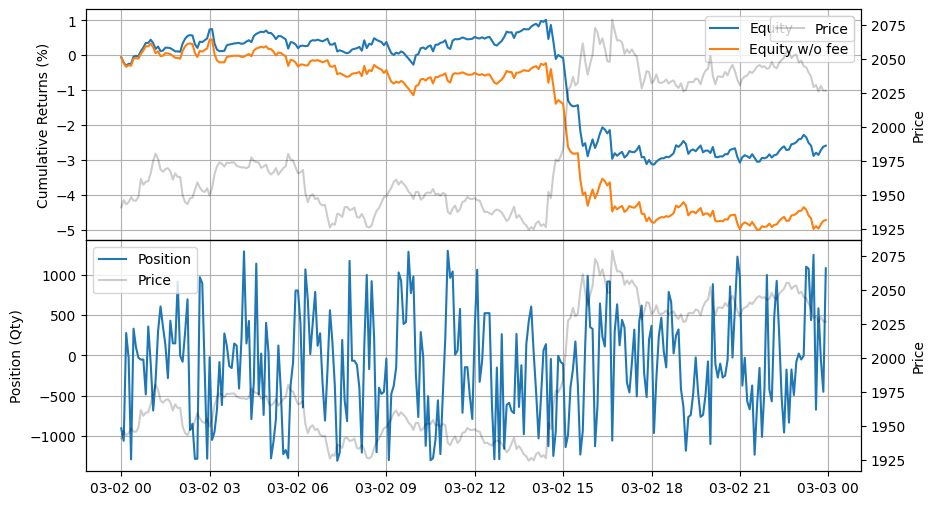

In [4]:
stats.plot()

In [11]:
%%time

roi_lb = 0
roi_ub = 3000

latency_data = np.concatenate(
# [np.load('latency/live_order_latency_{}.npz'.format(date))['data'] for date in range(20230501, 20230532)]
[np.load('usdm/feed_latency_ethusdc_{}.npz'.format(date))['data'] for date in range(20260301, 20260304)]
)

asset = (
    BacktestAsset()
        .data(['usdm/ethusdc_{}.npz'.format(date) for date in range(20260301, 20260304)])
        .initial_snapshot('usdm/ethusdc_20260228_eod.npz')
        .linear_asset(1.0) 
        .intp_order_latency(latency_data)
        .power_prob_queue_model(2)
        .no_partial_fill_exchange()
        .trading_value_fee_model(-0.00005, 0.0007)
        .tick_size(0.01)
        .lot_size(0.001)
        .roi_lb(roi_lb)    
        .roi_ub(roi_ub)
)

hbt = ROIVectorMarketDepthBacktest([asset])

recorder = Recorder(1, 30_000_000)

half_spread = 5
skew = 0.2
c1 = 10
depth = 0.025 # 2.5% from the mid price
interval = 1_000_000_000 # 1s
window = 3_600_000_000_000 / interval # 1hour
order_qty_dollar = 50_000
# order_qty_dollar = 500
max_position_dollar = order_qty_dollar * 50
grid_num = 1
grid_interval = hbt.depth(0).tick_size

obi_mm(
    hbt,
    recorder.recorder,
    half_spread,
    skew,
    c1,
    depth,
    interval,
    window,
    order_qty_dollar,
    max_position_dollar,
    grid_num,
    grid_interval,
    roi_lb,
    roi_ub
)

hbt.close()

recorder.to_npz('usdm/obi_ethusdc.npz')

CPU times: user 24.8 s, sys: 3.65 s, total: 28.4 s
Wall time: 23.4 s


In [12]:
data = np.load('usdm/obi_ethusdc.npz')['0']
stats = (
    LinearAssetRecord(data)
        .resample('5m')
        .stats(book_size=2_500_000)
)
stats.summary()

start,end,SR,Sortino,Return,MaxDrawdown,DailyNumberOfTrades,DailyTurnover,ReturnOverMDD,ReturnOverTrade,MaxPositionValue
datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-03-01 00:00:00,2026-03-03 23:55:00,-5.666376,-6.716278,-0.033762,0.072699,12641.965238,252.839223,-0.464402,-0.000045,2.5842e6


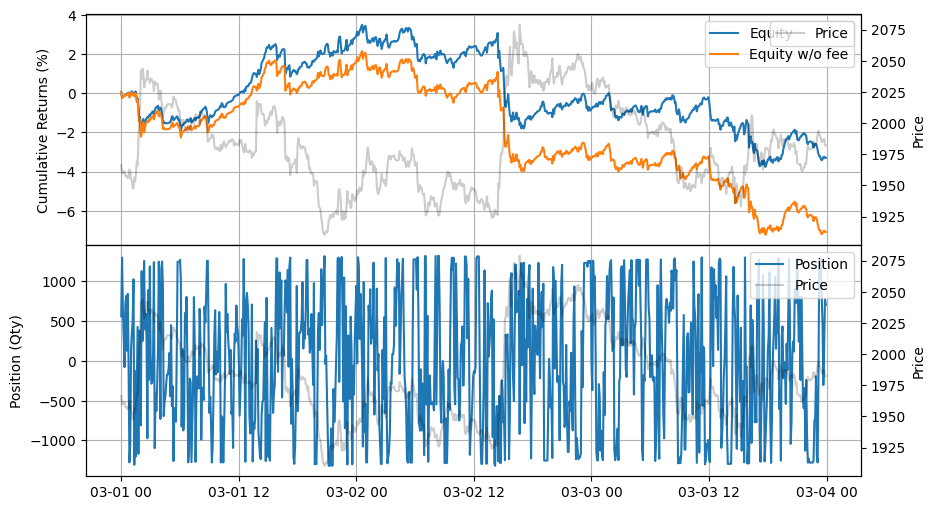

In [13]:
stats.plot()

Another approach is to generate trading volume to qualify as a market maker and receive rebates. This strategy involves maintaining a high skew and tight spread. While the strategy itself may not be profitable or may incur losses, it can help achieve market maker status.

另一种方法是通过增加交易量来成为市场做市商，并获得回扣。这种策略需要保持较大的价格偏离和较小的价差。虽然该策略本身可能无法盈利或者可能会造成亏损，但它有助于获得市场做市商的地位。

In [ ]:
%%time

roi_lb = 0
roi_ub = 3000

latency_data = np.concatenate(
# [np.load('latency/live_order_latency_{}.npz'.format(date))['data'] for date in range(20230501, 20230532)]
[np.load('usdm/feed_latency_ethusdc_{}.npz'.format(date))['data'] for date in range(20260301, 20260304)]
)

asset = (
    BacktestAsset()
        .data(['usdm/ethusdc_{}.npz'.format(date) for date in range(20260301, 20260304)])
        .initial_snapshot('usdm/ethusdc_20260228_eod.npz')
        .linear_asset(1.0) 
        .intp_order_latency(latency_data)
        .power_prob_queue_model(3)
        .no_partial_fill_exchange()
        .trading_value_fee_model(-0.00005, 0.0007)
        .tick_size(0.1)
        .lot_size(0.001)
        .roi_lb(roi_lb)    
        .roi_ub(roi_ub)
)

hbt = ROIVectorMarketDepthBacktest([asset])

recorder = Recorder(1, 30_000_000)

half_spread = 10
skew = 2
c1 = 20
depth = 0.001 # 0.1% from the mid price
interval = 500_000_000 # 500ms
window = 600_000_000_000 / interval # 10min
order_qty_dollar = 25_000
max_position_dollar = order_qty_dollar * 20
grid_num = 1
grid_interval = hbt.depth(0).tick_size

obi_mm(
    hbt,
    recorder.recorder,
    half_spread,
    skew,
    c1,
    depth,
    interval,
    window,
    order_qty_dollar,
    max_position_dollar,
    grid_num,
    grid_interval,
    roi_lb,
    roi_ub
)

recorder.to_npz('usdm/obi_vg_ethusdc.npz')

CPU times: user 24 s, sys: 3.91 s, total: 28 s
Wall time: 23.5 s


In [4]:
data = np.load('usdm/obi_vg_ethusdc.npz')['0']
stats = (
    LinearAssetRecord(data)
        .resample('5m')
        .stats(book_size=1_000_000)
)
stats.summary()

start,end,SR,Sortino,Return,MaxDrawdown,DailyNumberOfTrades,DailyTurnover,ReturnOverMDD,ReturnOverTrade,MaxPositionValue
datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-03-01 00:00:00,2026-03-03 23:55:00,89.814231,142.800449,0.072816,0.00489,34347.754345,858.694051,14.892363,0.000028,415325.76895


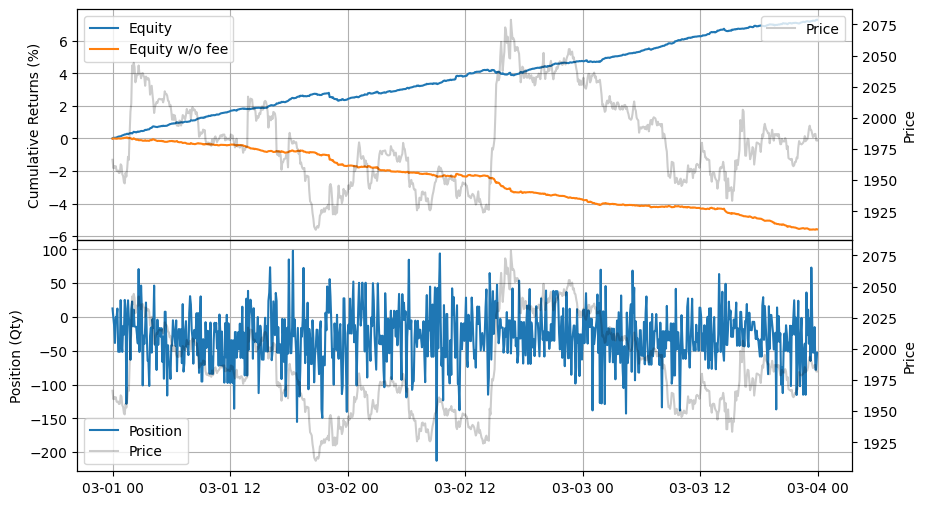

In [5]:
stats.plot()

## Update on Backtesting Results for 2025
## 2025 年回测结果更新

Updated backtesting results for February 2025 using the same parameters as in May 2023, except for the `power_prob_queue_model` parameter, which was changed from 2 to 3 to reflect market changes and a more challenging fill in the queue.

使用与 2023 年 5 月相同的参数（除了“power概率队列模型”参数外），对 2025 年 2 月的回测结果进行了更新。该参数从 2 改为 3，以反映市场变化以及队列中更复杂的填充情况。

In [3]:
import datetime

start_date = datetime.datetime.strptime('20260301', '%Y%m%d')
end_date = datetime.datetime.strptime('20260304', '%Y%m%d')

In [4]:
%%time

roi_lb = 0
roi_ub = 3000

latency_data = []
date = start_date
while date <= end_date:
    latency_data.append('usdm/feed_latency_ethusdc_{}.npz'.format(date.strftime('%Y%m%d')))
    date += datetime.timedelta(days=1)

data = []
date = start_date
while date <= end_date:
    data.append('usdm/ethusdc_{}.npz'.format(date.strftime("%Y%m%d")))
    date += datetime.timedelta(days=1)

asset = (
    BacktestAsset()
        .data(data)
        .initial_snapshot('usdm/ethusdc_20260228_eod.npz')
        .linear_asset(1.0) 
        .intp_order_latency(latency_data)
        .power_prob_queue_model(3)
        .no_partial_fill_exchange()
        .trading_value_fee_model(-0.00005, 0.0007)
        .tick_size(0.1)
        .lot_size(0.001)
        .roi_lb(roi_lb)    
        .roi_ub(roi_ub)
)

hbt = ROIVectorMarketDepthBacktest([asset])

recorder = Recorder(1, 30_000_000)

half_spread = 80
skew = 3.5
c1 = 160
depth = 0.025 # 2.5% from the mid price
interval = 1_000_000_000 # 1s
window = 3_600_000_000_000 / interval # 1hour
order_qty_dollar = 50_000
max_position_dollar = order_qty_dollar * 50
grid_num = 1
grid_interval = hbt.depth(0).tick_size

obi_mm(
    hbt,
    recorder.recorder,
    half_spread,
    skew,
    c1,
    depth,
    interval,
    window,
    order_qty_dollar,
    max_position_dollar,
    grid_num,
    grid_interval,
    roi_lb,
    roi_ub
)

hbt.close()

recorder.to_npz('usdm/obi_ethusdc_2026.npz')

: 

You can see from the following report that the order book imbalance continues to work consistently. However, the return per trade drops from 0.0139% to 0.0086%, including the 0.005% rebates. This again highlights the importance of rebates and the corresponding fee structure for market makers.

从以下报告中可以看出，订单簿失衡现象仍在持续存在且影响稳定。然而，每笔交易的回报率从 0.0139% 降至 0.0086%，其中包括 0.005% 的返利。这再次凸显了返利以及相应的交易商费用结构对于市场交易者的重要性。

In [ ]:
data = np.load('stats/obi_btcusdt_2025.npz')['0']
stats = (
    LinearAssetRecord(data)
        .resample('5m')
        .stats(book_size=2_500_000)
)
stats.summary()

In [ ]:
stats.plot()

In [ ]:
data = np.load('stats/obi_btcusdt_202505.npz')['0']
stats = (
    LinearAssetRecord(data)
        .resample('5m')
        .stats(book_size=2_500_000)
)
stats.summary()

In [ ]:
stats.plot()